# 000978 stage 3 — nonlinear embeddings (CEBRA / UMAP / Isomap)

Embeddings from `src/000978/03_nonlinear_embedding.py`, on **run** epochs. CEBRA
is behavior-aligned (position+speed, NOT the session label), so colouring by
run_session reveals learning drift rather than building it in.

1. 3-D embeddings coloured by run session and by position
2. CEBRA training loss
3. Position decoding (kNN, CV) per method and region
4. Cross-session drift — per-session embedding centroids (preview of 6b)


## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000978"):
    sys.path.insert(0, str(_root / "src" / _d))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from config import processed_dir, BIN_SIZE_S
DATA_PROCESSED = processed_dir("000978")
BIN_MS = int(BIN_SIZE_S * 1000)
METHODS = ["cebra", "umap", "isomap"]
plt.rcParams["figure.dpi"] = 100

## Pick a session/region

In [2]:
keys = sorted({f.stem.split("_")[2] for f in DATA_PROCESSED.glob(f"emb_umap_*_{BIN_MS}ms.npz")})
print("session keys:", keys)
SESSION = keys[0]   # change me (e.g. a single-file animal has 8 run sessions)
REGION = "CA1"
emb = {}
for m in METHODS:
    f = DATA_PROCESSED / f"emb_{m}_{SESSION}_{REGION}_{BIN_MS}ms.npz"
    if f.exists():
        emb[m] = np.load(f, allow_pickle=False)
print(f"{SESSION} {REGION}: methods", list(emb))

session keys: ['ER1', 'JS14', 'JS15', 'JS17', 'JS21', 'JS34', 'KL8', 'ZT2']
ER1 CA1: methods ['cebra', 'umap', 'isomap']


## 1. Embeddings by run session and position
Top: run session (1→N). Bottom: x-position.

C:\Users\proskurinm\AppData\Local\Temp\ipykernel_30736\3357613395.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


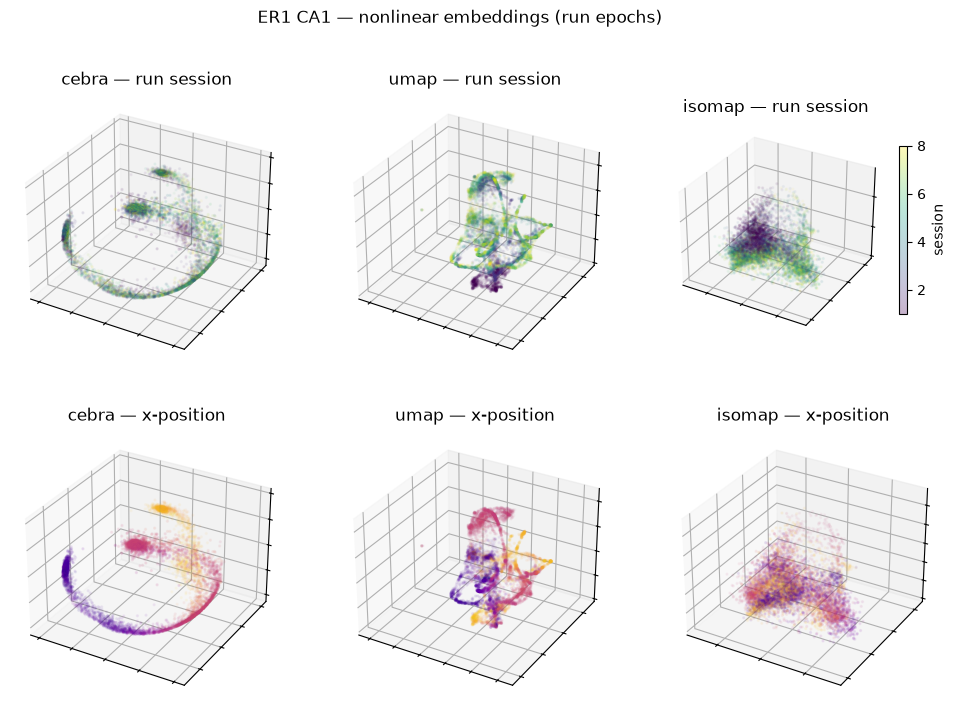

In [3]:
avail = list(emb)
fig = plt.figure(figsize=(4 * len(avail), 8))
for j, m in enumerate(avail):
    e = emb[m]["embedding"]; rs = emb[m]["run_session"]; pos = emb[m]["position"]
    ax = fig.add_subplot(2, len(avail), j + 1, projection="3d")
    s = ax.scatter(e[:, 0], e[:, 1], e[:, 2], c=rs, cmap="viridis", s=2, alpha=0.3)
    ax.set_title(f"{m} — run session"); [a.set_ticklabels([]) for a in (ax.xaxis, ax.yaxis, ax.zaxis)]
    if j == len(avail) - 1: fig.colorbar(s, ax=ax, label="session", shrink=0.6)
    ax2 = fig.add_subplot(2, len(avail), len(avail) + j + 1, projection="3d")
    ax2.scatter(e[:, 0], e[:, 1], e[:, 2], c=pos[:, 0], cmap="plasma", s=2, alpha=0.3)
    ax2.set_title(f"{m} — x-position"); [a.set_ticklabels([]) for a in (ax2.xaxis, ax2.yaxis, ax2.zaxis)]
fig.suptitle(f"{SESSION} {REGION} — nonlinear embeddings (run epochs)")
plt.tight_layout()

## 2. CEBRA training loss

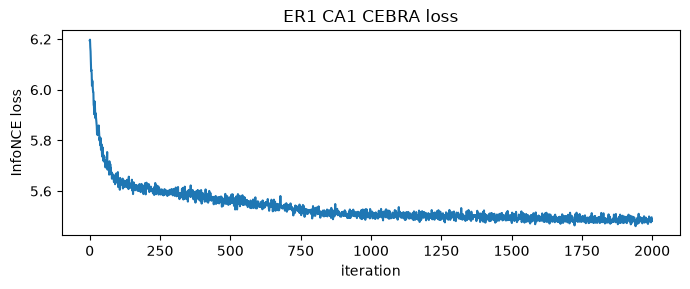

In [4]:
if "cebra" in emb and "cebra_loss" in emb["cebra"].files:
    plt.figure(figsize=(7, 3)); plt.plot(emb["cebra"]["cebra_loss"])
    plt.xlabel("iteration"); plt.ylabel("InfoNCE loss"); plt.title(f"{SESSION} {REGION} CEBRA loss")
    plt.tight_layout()
else:
    print("no CEBRA loss (CEBRA not run yet?)")

## 3. Position decoding (kNN, 5-fold CV) per method and region

region,CA1,PFC
method,,
cebra,0.969,0.908
isomap,0.363,0.394
umap,0.760,0.567


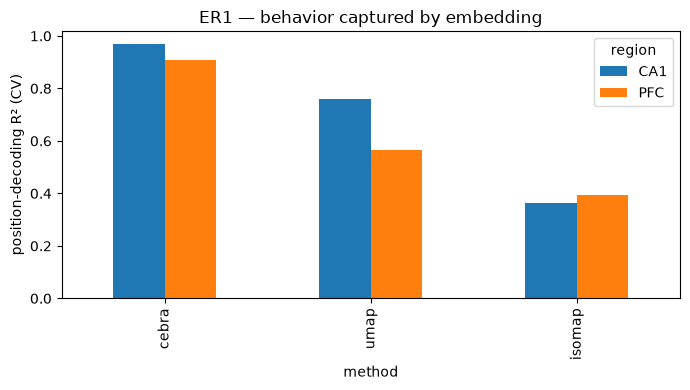

In [5]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
def decode_r2(e, pos):
    ok = np.isfinite(pos).all(axis=1)
    return cross_val_score(KNeighborsRegressor(15), e[ok], pos[ok], cv=5, scoring="r2").mean()
rows = []
for region in ["CA1", "PFC"]:
    for m in METHODS:
        f = DATA_PROCESSED / f"emb_{m}_{SESSION}_{region}_{BIN_MS}ms.npz"
        if f.exists():
            dd = np.load(f, allow_pickle=False)
            rows.append((region, m, decode_r2(dd["embedding"], dd["position"])))
tab = pd.DataFrame(rows, columns=["region", "method", "r2"]).pivot(index="method", columns="region", values="r2")
ax = tab.reindex(METHODS).plot.bar(figsize=(7, 4)); ax.set_ylabel("position-decoding R² (CV)")
ax.set_title(f"{SESSION} — behavior captured by embedding"); plt.tight_layout()
tab.round(3)

## 4. Cross-session drift (CEBRA)

Mean embedding position per run session. Systematic movement of the centroid
across sessions = learning-related manifold drift, quantified properly in 6b.

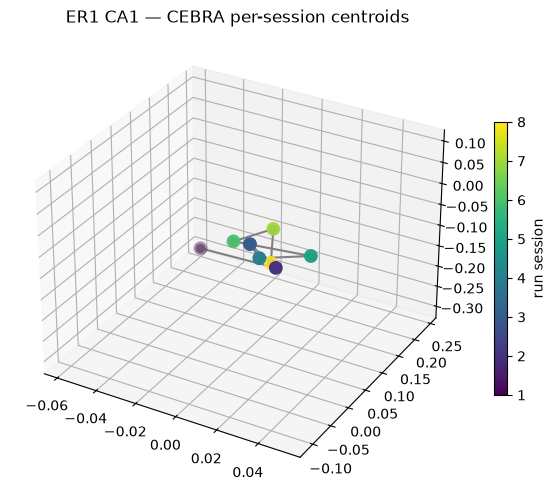

In [6]:
if "cebra" in emb:
    e = emb["cebra"]["embedding"]; rs = emb["cebra"]["run_session"]
    sessions = sorted(np.unique(rs).tolist())
    cent = np.vstack([e[rs == s].mean(0) for s in sessions])
    fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection="3d")
    ax.plot(cent[:, 0], cent[:, 1], cent[:, 2], "-o", color="gray", zorder=1)
    sc = ax.scatter(cent[:, 0], cent[:, 1], cent[:, 2], c=sessions, cmap="viridis", s=80, zorder=2)
    ax.set_title(f"{SESSION} {REGION} — CEBRA per-session centroids")
    fig.colorbar(sc, ax=ax, label="run session", shrink=0.6); plt.tight_layout()
else:
    print("CEBRA not available")

---
**Next:** 6b session-sequence alignment (Procrustes/CCA of each session's
embedding vs. the last, as a function of session number) and 6c sleep-epoch
projection. ZT2's two files need a global 1-8 session order first.